In [4]:
import matplotlib.pyplot as plt
import numpy as np

def xor_bits(bit1, bit2):
    """Perform XOR operation on two bits."""
    return '0' if bit1 == bit2 else '1'

def crc_divide(dividend, divisor):
    """Performs modulo-2 division used in CRC."""
    l_divisor = len(divisor)

    # The current segment of the dividend being processed, effectively the remainder after each step
    # It must always be of length l_divisor for the XOR operation
    tmp = list(dividend[0 : l_divisor]) # Convert to list for mutable characters

    # Iterate through the rest of the dividend
    for i in range(l_divisor, len(dividend)):
        # If the leading bit of the current segment is '1', perform XOR
        if tmp[0] == '1':
            for j in range(l_divisor):
                tmp[j] = xor_bits(tmp[j], divisor[j])

        # Shift the current segment left by one bit (discard the leading bit)
        # and append the next bit from the dividend
        tmp = tmp[1:] + [dividend[i]]

    # After the loop, the remaining 'tmp' represents the remainder.
    # We need to perform one final XOR if the leading bit is '1'.
    if tmp[0] == '1':
        for j in range(l_divisor):
            tmp[j] = xor_bits(tmp[j], divisor[j])

    # The actual CRC remainder is typically (l_divisor - 1) bits.
    # For a generator polynomial of degree N, the remainder is N bits.
    # A polynomial like X^3 + X + 1 corresponds to a 4-bit divisor '1011',
    # meaning degree 3, so the remainder is 3 bits (l_divisor - 1).
    return "".join(tmp[1:]) # Return the (l_divisor - 1) bit remainder

def encode_data(data, key):
    """Appends trailing zeros and calculates the CRC remainder."""
    l_key = len(key)
    # The appended data should be 'l_key - 1' zeros for the remainder calculation
    appended_data = data + '0' * (l_key - 1)
    remainder = crc_divide(appended_data, key)
    return remainder, data + remainder

def verify_data(received_data, key):
    """Checks if the received data has errors (remainder should be all 0s)."""
    remainder = crc_divide(received_data, key)
    return '1' not in remainder

# --- Execution & Demonstration ---
# Standard CRC-3 Polynomial: X^3 + X + 1 -> '1011' (degree 3, so remainder will be 3 bits)
generator_poly = "1011"
original_bits = "11010011"

print("--- SENDER SIDE ---")
print(f"Original Data:      {original_bits}")
print(f"Generator (Key):    {generator_poly}")
remainder, transmitted_frame = encode_data(original_bits, generator_poly)
print(f"Calculated CRC:     {remainder}")
print(f"Transmitted Frame:  {transmitted_frame}\n")

print("--- RECEIVER SIDE (NO ERROR) ---")
is_valid_clean = verify_data(transmitted_frame, generator_poly)
print(f"Received Frame:     {transmitted_frame}")
print(f"Is data error-free? {is_valid_clean}\n")

print("--- RECEIVER SIDE (WITH BIT ERROR) ---")
# Corrupt the 4th bit (index 3) to simulate network noise
corrupted_frame = transmitted_frame[:3] + ('1' if transmitted_frame[3] == '0' else '0') + transmitted_frame[4:]
is_valid_corrupted = verify_data(corrupted_frame, generator_poly)
print(f"Corrupted Frame:    {corrupted_frame}")
print(f"Is data error-free? {is_valid_corrupted}")

--- SENDER SIDE ---
Original Data:      11010011
Generator (Key):    1011
Calculated CRC:     011
Transmitted Frame:  11010011011

--- RECEIVER SIDE (NO ERROR) ---
Received Frame:     11010011011
Is data error-free? True

--- RECEIVER SIDE (WITH BIT ERROR) ---
Corrupted Frame:    11000011011
Is data error-free? False


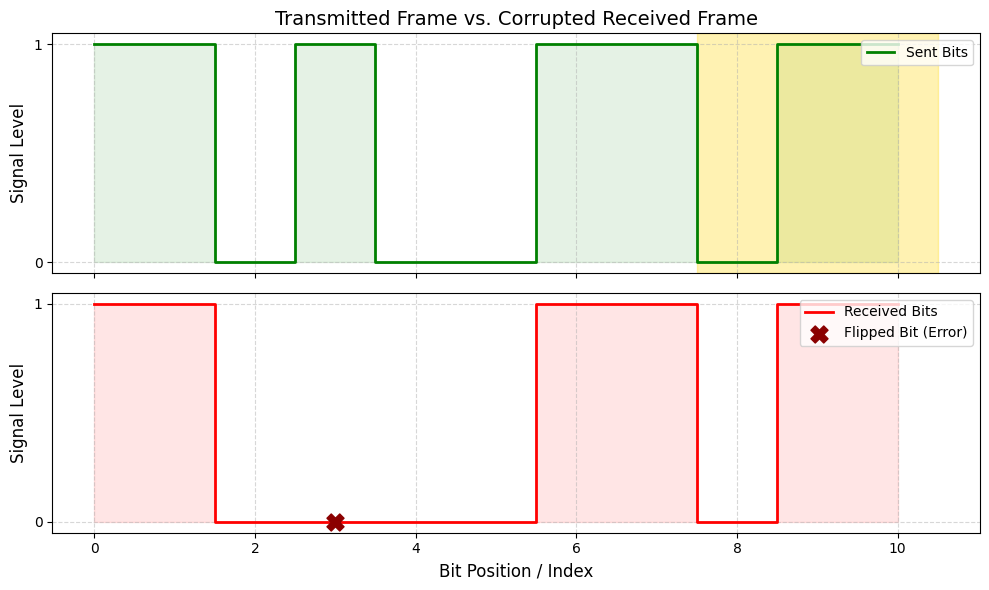

📊 Visual Verification Summary:
-> Sending standard frame remainder check: Clean data returns 0.
-> Modified bit at index [3] causes mathematical modulo-2 failure.
-> Receiver successfully rejects the frame!


In [5]:
# Convert bit strings to integer lists for plotting
tx_signal = [int(b) for b in transmitted_frame]
rx_signal = [int(b) for b in corrupted_frame]
time_steps = np.arange(len(tx_signal))

# Setup the plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot 1: Transmitted Signal
ax1.step(time_steps, tx_signal, where='mid', color='green', linewidth=2, label='Sent Bits')
ax1.fill_between(time_steps, tx_signal, step="mid", alpha=0.1, color='green')
ax1.set_title("Transmitted Frame vs. Corrupted Received Frame", fontsize=14)
ax1.set_ylabel("Signal Level", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_yticks([0, 1])
ax1.legend(loc='upper right')

# Highlight the CRC bits region on sender side
crc_start_idx = len(original_bits)
ax1.axvspan(crc_start_idx - 0.5, len(tx_signal) - 0.5, color='gold', alpha=0.3, label='CRC Checksum')

# Plot 2: Received Signal with Corrupted Bit Highlighted
ax2.step(time_steps, rx_signal, where='mid', color='red', linewidth=2, label='Received Bits')
ax2.fill_between(time_steps, rx_signal, step="mid", alpha=0.1, color='red')
ax2.set_xlabel("Bit Position / Index", fontsize=12)
ax2.set_ylabel("Signal Level", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_yticks([0, 1])

# Pinpoint the exact error location
error_idx = 3
ax2.scatter(error_idx, rx_signal[error_idx], color='darkred', s=150, zorder=5, marker='X', label='Flipped Bit (Error)')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"📊 Visual Verification Summary:")
print(f"-> Sending standard frame remainder check: Clean data returns 0.")
print(f"-> Modified bit at index [{error_idx}] causes mathematical modulo-2 failure.")
print(f"-> Receiver successfully rejects the frame!")


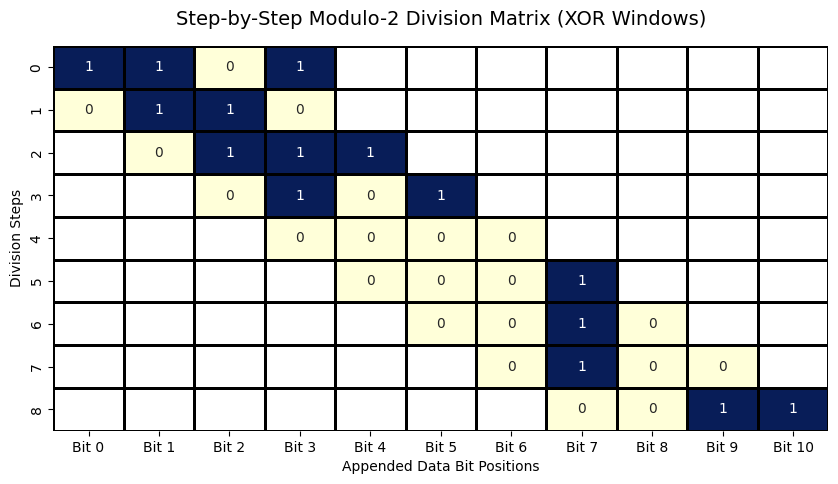

In [8]:
import seaborn as sns

# Re-running the encoding math to capture the step-by-step states
data = "11010011"
key = "1011"
l_key = len(key)
appended_data = data + '0' * (l_key - 1)

steps_matrix = []
current_window = list(appended_data[0:l_key]) # Initialize the first window as a list of characters

# Log the initial state of the window at the beginning of appended_data
# All other bits are inactive (-1)
initial_row = [int(b) for b in current_window] + [-1] * (len(appended_data) - l_key)
steps_matrix.append(initial_row)

# The main loop for modulo-2 division, moving the window one bit at a time
# `i` represents the index of the bit from `appended_data` that will be appended next
for i in range(l_key, len(appended_data) + 1): # loop up to and including len(appended_data) for the final XOR

    # If the leading bit of the current window is '1', perform XOR with the key
    if current_window[0] == '1':
        for j in range(l_key):
            current_window[j] = '0' if current_window[j] == key[j] else '1' # Re-using XOR logic inline

    # After XOR, log the state of the *current window* (remainder of this step)
    # This window is positioned starting at index `i - l_key` in the `appended_data` context.
    row_to_add = [-1] * (i - l_key) # Padding before the window
    row_to_add += [int(b) for b in current_window] # The current window
    row_to_add += [-1] * (len(appended_data) - i) # Padding after the window
    steps_matrix.append(row_to_add)

    # Shift the window: discard the leading bit and append the next bit from appended_data
    # This shift happens for all steps except the very last one where no more bits are appended.
    if i < len(appended_data):
        current_window = current_window[1:] + [appended_data[i]]
    else:
        # If i is len(appended_data), it means we have processed all bits.
        # The last state in steps_matrix already contains the result of the final XOR.
        # No further shift or append is needed.
        pass

# The `steps_matrix` now contains the state of the `l_key`-bit window at each step.
# The final remainder is `current_window[1:]` (which is what crc_divide would return for CRC bits).

# Plotting the Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(steps_matrix, annot=True, cmap="YlGnBu", cbar=False, linewidths=1, linecolor="black",
            mask=np.array(steps_matrix) == -1, xticklabels=[f"Bit {i}" for i in range(len(appended_data))])
plt.title("Step-by-Step Modulo-2 Division Matrix (XOR Windows)", fontsize=14, pad=15)
plt.xlabel("Appended Data Bit Positions")
plt.ylabel("Division Steps")
plt.show()

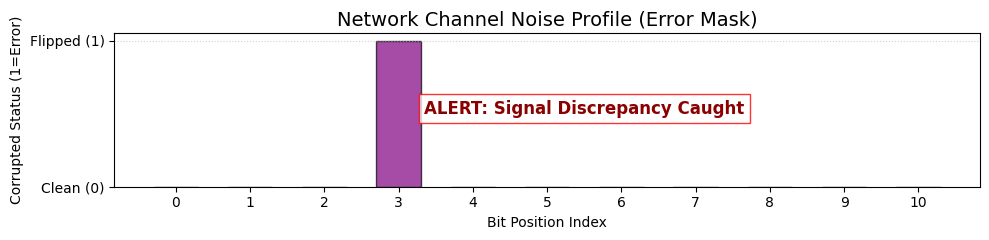

In [9]:
# Compute the pure error mask (where 1 indicates a corrupted bit)
error_mask = [t_bit ^ r_bit for t_bit, r_bit in zip(tx_signal, rx_signal)]

plt.figure(figsize=(10, 2.5))
plt.bar(time_steps, error_mask, color='purple', alpha=0.7, edgecolor='black', width=0.6)
plt.title("Network Channel Noise Profile (Error Mask)", fontsize=14)
plt.xlabel("Bit Position Index")
plt.ylabel("Corrupted Status (1=Error)")
plt.xticks(time_steps)
plt.yticks([0, 1], ["Clean (0)", "Flipped (1)"])
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Add a warning banner text onto the plot area
plt.text(len(time_steps)/2, 0.5, "ALERT: Signal Discrepancy Caught",
         color='darkred', weight='bold', fontsize=12, ha='center',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))

plt.tight_layout()
plt.show()


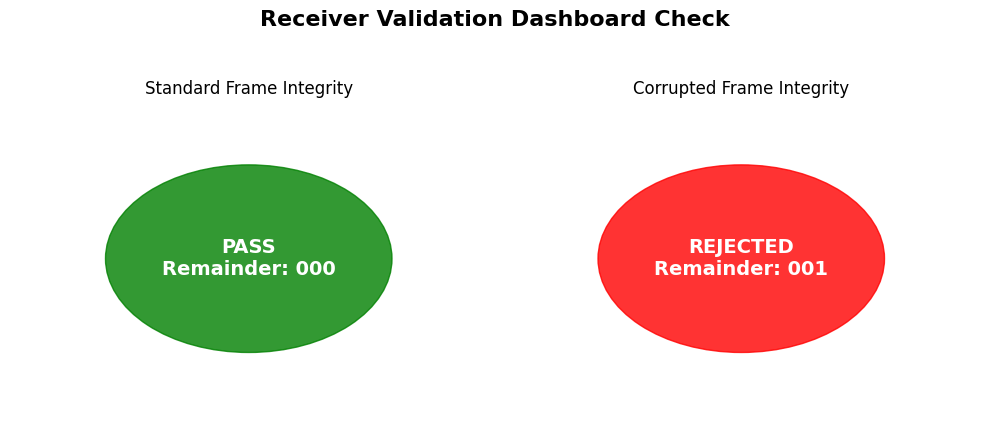

In [10]:
# Calculate actual remainders for confirmation
clean_remainder = crc_divide(transmitted_frame, generator_poly)
corrupted_remainder = crc_divide(corrupted_frame, generator_poly)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Left Indicator: Clean Frame
ax1.add_patch(plt.Circle((0.5, 0.5), 0.3, color='green', alpha=0.8))
ax1.text(0.5, 0.5, f"PASS\nRemainder: {clean_remainder}", color='white',
         weight='bold', fontsize=14, ha='center', va='center')
ax1.set_title("Standard Frame Integrity")
ax1.axis('off')

# Right Indicator: Corrupted Frame
ax2.add_patch(plt.Circle((0.5, 0.5), 0.3, color='red', alpha=0.8))
ax2.text(0.5, 0.5, f"REJECTED\nRemainder: {corrupted_remainder}", color='white',
         weight='bold', fontsize=14, ha='center', va='center')
ax2.set_title("Corrupted Frame Integrity")
ax2.axis('off')

plt.suptitle("Receiver Validation Dashboard Check", fontsize=16, weight='bold', y=1.05)
plt.tight_layout()
plt.show()
